# Aktivitas Hands-on: Prediksi Gaji Menggunakan Regresi Linear

Nama : Novi Shandi

NIM : 240401010291

Mata Kuliah : Pengantar Data Science

Pertemuan 7 — Pengantar Machine Learning: Regresi Linear

In [13]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Import Library

Pada praktikum ini digunakan beberapa library utama, yaitu:

* NumPy untuk membuat dataset sintetis.
* Pandas untuk pengolahan data.
* Matplotlib dan Seaborn untuk visualisasi.
* Scikit-Learn untuk preprocessing, pembuatan model, dan evaluasi regresi linear.

In [14]:
# =========================================================
# MEMBUAT DATASET SINTETIS
# =========================================================

np.random.seed(42)

n = 300

pengalaman = np.random.uniform(0, 20, n)

edu = np.random.choice(
    [0, 1, 2],
    n
)

kota = np.random.choice(
    ['Jakarta', 'Surabaya', 'Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print(df.head())

   pengalaman  edu      kota       gaji
0    7.490802    0   Jakarta  21.953247
1   19.014286    1   Jakarta  46.721665
2   14.639879    2  Surabaya  34.952649
3   11.973170    2   Bandung  32.437143
4    3.120373    2   Jakarta  17.384265


## Penjelasan Dataset

Dataset yang digunakan merupakan dataset sintetis yang mensimulasikan kondisi dunia kerja. Besarnya gaji dipengaruhi oleh pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja.

Kolom target yang akan diprediksi adalah `gaji`.

In [15]:
# =========================================================
# EXPLORATORY DATA ANALYSIS
# =========================================================

print("Shape Dataset:")
print(df.shape)

print("\nStatistik Deskriptif:")
print(df.describe().round(2))

Shape Dataset:
(300, 4)

Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


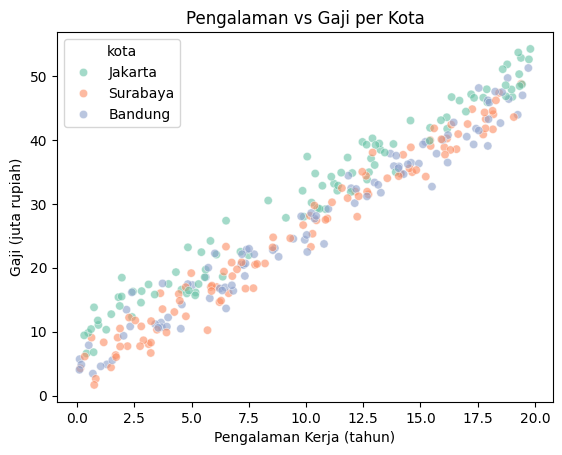

In [16]:
# Scatter Plot

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title(
    'Pengalaman vs Gaji per Kota'
)

plt.xlabel(
    'Pengalaman Kerja (tahun)'
)

plt.ylabel(
    'Gaji (juta rupiah)'
)

plt.show()

### What?

Grafik menunjukkan bahwa semakin tinggi pengalaman kerja, semakin tinggi pula gaji yang diterima.

### So what?

Hubungan positif ini menunjukkan bahwa pengalaman kerja merupakan faktor penting dalam menentukan besarnya gaji.

### Now what?

Variabel pengalaman layak digunakan sebagai salah satu prediktor utama dalam model regresi linear.

In [17]:
# =========================================================
# ONE HOT ENCODING
# =========================================================

df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print(
    df.columns.tolist()
)

# Pisahkan fitur dan target

X = df.drop(
    'gaji',
    axis=1
)

y = df['gaji']

['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


## One-Hot Encoding

Kolom `kota` merupakan data kategorikal sehingga perlu diubah menjadi data numerik menggunakan One-Hot Encoding agar dapat diproses oleh algoritma machine learning.

In [18]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    f"Train : {X_train.shape[0]} data"
)

print(
    f"Test  : {X_test.shape[0]} data"
)

Train : 240 data
Test  : 60 data


In [19]:
# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_s = scaler.fit_transform(
    X_train
)

X_test_s = scaler.transform(
    X_test
)

## Feature Scaling

StandardScaler digunakan untuk menyamakan skala antar fitur sehingga proses pembelajaran model menjadi lebih stabil dan akurat.

In [20]:
# =========================================================
# MEMBUAT MODEL REGRESI
# =========================================================

model = LinearRegression()

model.fit(
    X_train_s,
    y_train
)

print(
    f"β₀ (intercept): {model.intercept_:.3f}"
)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
})

coef_df = coef_df.sort_values(
    'Koefisien',
    ascending=False
)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


## Interpretasi Koefisien

Koefisien positif menunjukkan bahwa kenaikan nilai fitur tersebut akan meningkatkan prediksi gaji. Sebaliknya, koefisien negatif menunjukkan penurunan nilai prediksi gaji.

In [21]:
# =========================================================
# EVALUASI MODEL
# =========================================================

y_pred = model.predict(
    X_test_s
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("=== METRIK EVALUASI ===")

print(
    f"MAE = {mae:.3f}"
)

print(
    f"RMSE = {rmse:.3f}"
)

print(
    f"R² = {r2:.4f}"
)

print(
    f"Selisih RMSE-MAE = {(rmse-mae):.3f}"
)

=== METRIK EVALUASI ===
MAE = 1.649
RMSE = 2.123
R² = 0.9740
Selisih RMSE-MAE = 0.474


### What?

Model menghasilkan nilai MAE, RMSE, dan R² sebagai ukuran performa prediksi.

### So what?

Semakin kecil nilai MAE dan RMSE serta semakin mendekati 1 nilai R², maka model semakin baik dalam memprediksi gaji.

### Now what?

Hasil evaluasi dapat digunakan untuk menentukan apakah model sudah cukup baik atau perlu pengembangan lebih lanjut.

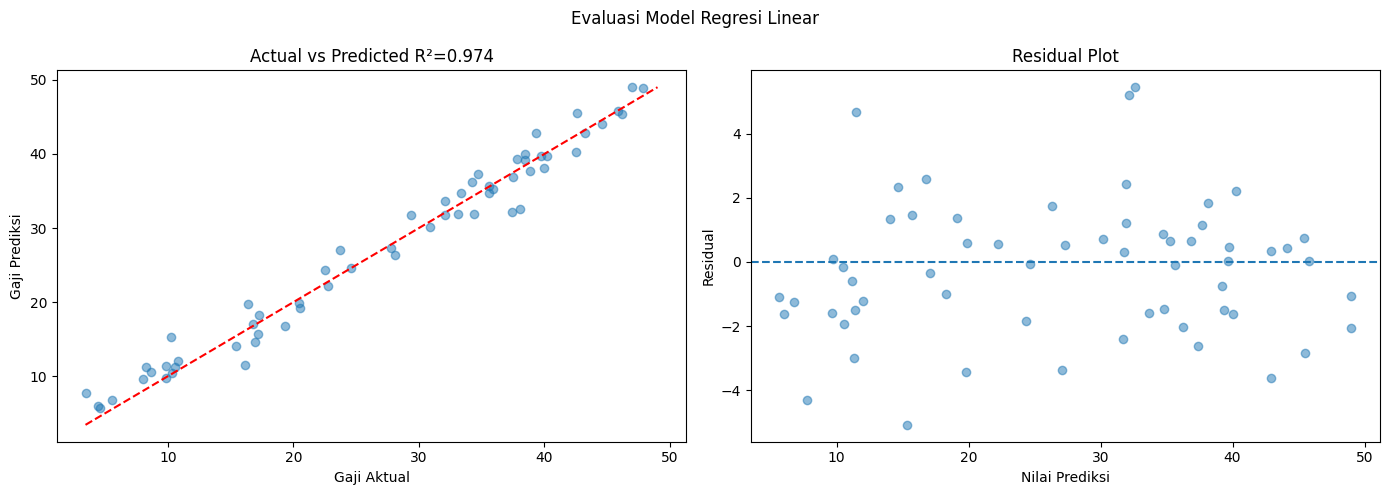

In [22]:
# =========================================================
# VISUALISASI HASIL
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Actual vs Predicted

axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--'
)

axes[0].set_title(
    f'Actual vs Predicted R²={r2:.3f}'
)

axes[0].set_xlabel(
    'Gaji Aktual'
)

axes[0].set_ylabel(
    'Gaji Prediksi'
)

# Residual Plot

residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5
)

axes[1].axhline(
    0,
    linestyle='--'
)

axes[1].set_title(
    'Residual Plot'
)

axes[1].set_xlabel(
    'Nilai Prediksi'
)

axes[1].set_ylabel(
    'Residual'
)

plt.suptitle(
    'Evaluasi Model Regresi Linear'
)

plt.tight_layout()

plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Kesimpulan

Pada praktikum ini telah dibuat model Regresi Linear untuk memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja.

Tahapan yang dilakukan meliputi:

* pembuatan dataset sintetis,
* eksplorasi data,
* preprocessing,
* pelatihan model,
* evaluasi model,
* serta visualisasi hasil prediksi.

Berdasarkan nilai MAE, RMSE, dan R², model mampu mempelajari pola hubungan antara fitur dan target dengan cukup baik sehingga dapat digunakan untuk melakukan prediksi gaji.